# 1. Data Preparation

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r"E:\BA.GENAI\ml-assessment-kirankumari\data\q2_customers.csv")
print("Shape:", df.shape)
print(df.head())

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("\nScaling complete!")

Shape: (500, 6)
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Scaling complete!


## Why Scaling is Essential Before K-Means

K-Means calculates distance between data points to form clusters.
If features are on different scales, larger-valued features will 
dominate the distance calculation unfairly.

Example from this dataset:
| Feature | Range |
|---|---|
| age | 18 — 70 |
| annual_spend | 5000 — 100000 |
| visits_per_month | 1 — 30 |
| basket_size | 10 — 500 |
| days_since_last_visit | 0 — 365 |
| num_categories_purchased | 1 — 10 |

Without scaling, `annual_spend` (range ~95000) would completely 
dominate over `num_categories_purchased` (range ~9), making 
clustering biased and meaningless.

StandardScaler converts all features to mean=0 and std=1,
giving equal importance to every feature during clustering.

# 2. K—Elbow Method

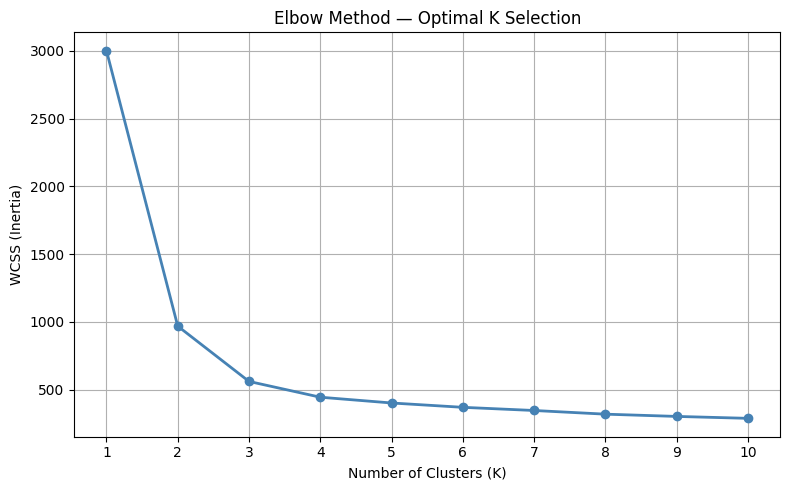

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Compute WCSS for K = 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal K Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.show()

## Choosing Optimal K — Elbow Method

| K | Observation |
|---|---|
| K=1 | WCSS very high (~3000) |
| K=2 | Sharp drop (~1000) |
| K=3 | Significant drop (~550) — Elbow Point |
| K=4 onwards | Curve flattens, minimal improvement |

## Optimal K = 3

The elbow point is clearly visible at K=3.

- From K=1 to K=3, WCSS drops steeply — adding clusters significantly improves cohesion.
- After K=3, the curve flattens — adding more clusters gives very little improvement in WCSS.
- This "elbow" shape indicates K=3 as the optimal number of clusters, balancing model simplicity with cluster quality.

Therefore, K=3 will be used for K-Means clustering.

# 3. K - means clustering 

In [3]:
# Fit K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster column added!")
print("\nCluster Value Counts:")
print(df['cluster'].value_counts())

# Cluster Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # exclude cluster column
)
centroids.index.name = 'Cluster'
print("\nCluster Centroids:")
print(centroids.round(2))

Cluster column added!

Cluster Value Counts:
cluster
0    170
2    165
1    165
Name: count, dtype: int64

Cluster Centroids:
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


## K-Means Cluster Interpretation — Business Terms

| Feature | Cluster 0 | Cluster 1 | Cluster 2 |
|---|---|---|---|
| Age | 24.68 (Young) | 56.77 (Senior) | 40.39 (Middle-aged) |
| Annual Spend | ₹14,847 (Low) | ₹89,413 (High) | ₹43,341 (Medium) |
| Visits/Month | 14.34 (Frequent) | 2.53 (Rare) | 8.19 (Moderate) |
| Basket Size | 558 (Small) | 5,531 (Large) | 2,022 (Medium) |
| Days Since Last Visit | 9 (Recent) | 105 (Inactive) | 35 (Occasional) |
| Categories Purchased | 2.11 (Narrow) | 7.52 (Broad) | 4.42 (Moderate) |

## Business Interpretation:

**Cluster 0 — "Young Frequent Low-Spenders" (170 customers)**
Young customers (~25 years) who visit very frequently (14x/month)
but spend very little per visit. They buy from fewer categories
with small basket sizes. Likely students or budget-conscious shoppers.
Strategy: Offer combo deals and loyalty rewards to increase basket size.

**Cluster 1 — "Senior High-Value Inactive Spenders" (165 customers)**
Older customers (~57 years) who spend the most (₹89,413/year) but
visit rarely (2.5x/month) and have not visited in ~105 days.
They buy across many categories with large basket sizes.
Strategy: Re-engagement campaigns, personalized offers to bring them back.

**Cluster 2 — "Middle-aged Moderate Engagers" (165 customers)**
Middle-aged customers (~40 years) with moderate spending and visit
frequency. They represent the most balanced segment.
Strategy: Upsell premium products to convert them into high-value customers.

# 4. Dimensionality Reduction with PCA

In [6]:
from sklearn.decomposition import PCA

feature_cols = ['age', 'annual_spend', 'visits_per_month', 
                'basket_size', 'days_since_last_visit', 
                'num_categories_purchased']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Original shape:', X_scaled.shape)
print('Reduced shape :', X_pca.shape)

Original shape: (500, 6)
Reduced shape : (500, 2)


In [7]:
print('=' * 50)
print('      Explained Variance Ratio')
print('=' * 50)
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.4f}  →  {var*100:.2f}%')

total = sum(pca.explained_variance_ratio_)
print(f'\n  Total variance captured: {total*100:.2f}%')
print('=' * 50)

      Explained Variance Ratio
  PC1: 0.8356  →  83.56%
  PC2: 0.0557  →  5.57%

  Total variance captured: 89.13%


In [8]:
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
).round(4)

print('Feature Loadings:')
print()
print(loadings_df.to_string())

Feature Loadings:

                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


## Interpretation of PC1 and PC2

### PC1 — "Overall Customer Value & Engagement" (83.56%)
Five features contribute equally (~0.41) to PC1:
- `annual_spend`, `basket_size`, `num_categories_purchased`, 
  `age`, `days_since_last_visit` → Positive
- `visits_per_month` → Negative (-0.41)

- **High PC1** = High spend, large basket, diverse categories = Premium Customer
- **Low PC1** = Frequent visits, low spend = Bargain Hunter

### PC2 — "Recency of Visit" (5.57%)
- `days_since_last_visit` → +0.9112 (dominant feature)
- All other features ≈ 0 (negligible)

- **High PC2** = Not visited in a long time = Lapsed Customer
- **Low PC2** = Visited very recently = Active Customer

### Summary

| Component | Business Meaning | Variance Captured |
|---|---|---|
| PC1 | Customer Value & Engagement | 83.56% |
| PC2 | Recency of Visit | 5.57% |
| **Total** | | **89.13%** |

By reducing 6 features to 2 principal components, 89.13% of the 
original information is retained — demonstrating PCA's effectiveness 
for dimensionality reduction.

# 5.Cluster Visualisation

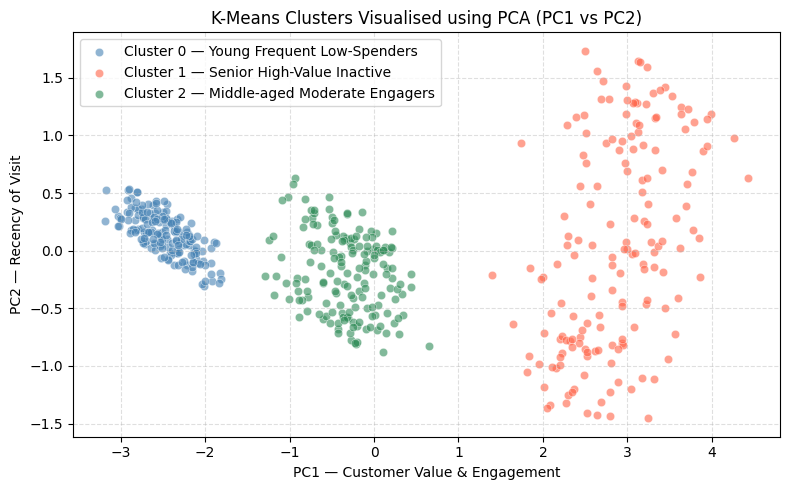

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

colors = ['steelblue', 'tomato', 'seagreen']
labels = ['Cluster 0 — Young Frequent Low-Spenders',
          'Cluster 1 — Senior High-Value Inactive',
          'Cluster 2 — Middle-aged Moderate Engagers']

for i in range(3):
    mask = df['cluster'] == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[i],
        label=labels[i],
        alpha=0.6,
        edgecolors='white',
        linewidths=0.4
    )

plt.title('K-Means Clusters Visualised using PCA (PC1 vs PC2)')
plt.xlabel('PC1 — Customer Value & Engagement')
plt.ylabel('PC2 — Recency of Visit')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()